In [114]:
import pandas as pd

# 1. Load your financial data
# Replace 'financial_returns.csv' with your actual file path (CSV, Excel, etc.)
# We assume dates are in the first column and set them as the index

df = pd.read_csv('./data/concat_hf_data.csv', parse_dates=True).set_index('date')
df.index = pd.to_datetime(df.index)

df = df.drop(columns=['arr', 'm1', 'tidan', 'bam'], axis=1)
# df = df[['bam', 'four_world', 'quanstream', 'm1', 'vadantia', 'sp500', 'arr']]
# 2. Compute the correlation matrix
# 'min_periods' ensures we have at least N overlapping data points 
# to trust the correlation score. Adjust this based on your dataset size.
corr_matrix = df.corr(method='pearson', min_periods=3)

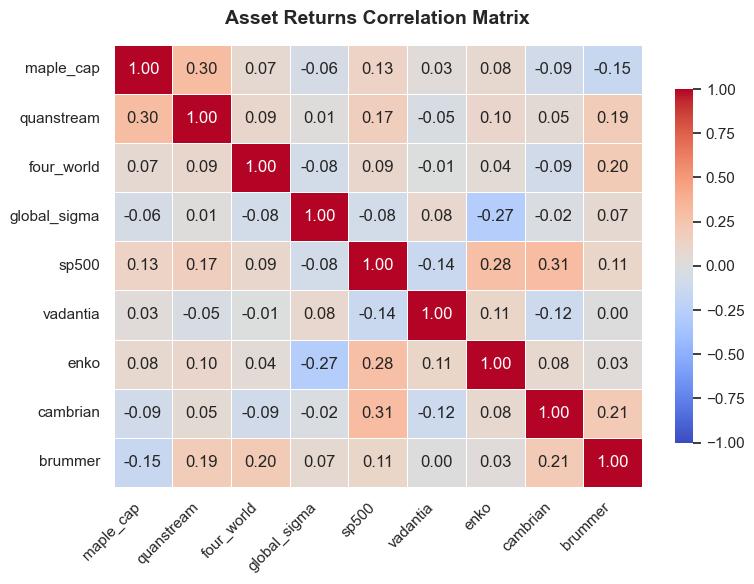

In [115]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme()

# # 1. Assuming you already have your correlation matrix from the previous step
# # (We will use mock data here just so the script runs standalone)
# np.random.seed(42)
# columns = ['Gold', 'S&P 500', 'US 10Y Bond', 'Bitcoin', 'Crude Oil']
# mock_data = pd.DataFrame(np.random.randn(100, 5), columns=columns)
# corr_matrix = mock_data.corr()

# 2. Set up the matplotlib figure
plt.figure(figsize=(8, 6))

# 3. Create a mask to hide the upper triangle (optional, but cleaner)
# mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# 4. Generate a custom diverging colormap (Coolwarm is great for correlations)
# It maps -1 to deep blue, 0 to white/gray, and +1 to deep red
cmap = sns.diverging_palette(230, 20, as_cmap=True)

# 5. Draw the heatmap
sns.heatmap(
    corr_matrix, 
    # mask=mask,          # Applies the upper-triangle mask
    cmap='coolwarm',    # Good color scale for -1 to 1 ranges
    vmax=1.0,           # Anchor the maximum value of the scale
    vmin=-1.0,          # Anchor the minimum value of the scale
    center=0,           # Center the colorbar at 0
    annot=True,         # Write the correlation numbers inside the squares
    fmt=".2f",          # Limit numbers to 2 decimal places
    linewidths=0.5,     # Add thin lines between the squares
    cbar_kws={"shrink": 0.8} # Slightly shrink the colorbar so it fits nicely
)

plt.title('Asset Returns Correlation Matrix', fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right') # Rotate asset labels so they don't overlap
plt.yticks(rotation=0)

# 6. Show or save the plot
plt.tight_layout()
plt.show()
# plt.savefig('correlation_heatmap.png', dpi=300) # Uncomment to save

In [116]:
df = df[df.index >= pd.to_datetime('2020-01-01')]

df.head()

,maple_cap,quanstream,four_world,global_sigma,sp500,vadantia,enko,cambrian,brummer
date,,,,,,,,,
2020-01-01,NaN,-0.010088,0.0215,0.0001,-0.000392,-0.0033,0.0237,0.204,0.0180
2020-02-01,NaN,-0.035018,-0.0206,0.0119,-0.082319,0.0185,0.0285,0.007,-0.0051
2020-03-01,-0.0200,-0.072548,-0.0342,0.0126,-0.123513,0.0262,0.0430,-0.036,-0.0446
2020-04-01,0.0272,0.083602,0.0196,0.0115,0.128194,-0.0433,0.0331,0.112,0.0001
2020-05-01,0.0004,0.060922,0.0157,0.0085,0.047627,-0.0039,0.0336,0.001,0.0581


In [117]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 1. Clean data: Drop any rows with missing returns
df_clean = df.dropna(axis=0)

print(df_clean.head())
print('\n')
# 2. Standardize features (Mean=0, Variance=1)
scaler = StandardScaler()
scaled_returns = scaler.fit_transform(df_clean)

# 3. Initialize and fit PCA
# We'll look at the top 3 dominant risk factors (PCs)
n_factors = 9
pca = PCA(n_components=n_factors)
pca.fit(scaled_returns)

# 4. Extract Explained Variance (How much total risk does each factor explain?)
for i, var in enumerate(pca.explained_variance_ratio_):
    print(f"Principal Component {i+1} explains {var*100:.2f}% of total portfolio risk.")

# 5. Create the Risk Breakdown Matrix (Loadings)
# Loadings represent the correlation between your original columns and the risk factors
loadings = pd.DataFrame(
    pca.components_.T, 
    columns=[f'Risk_Factor_{i+1}' for i in range(n_factors)],
    index=df_clean.columns
)

print("\n--- Risk Exposure Breakdown per Column ---")
print(loadings.round(3))

            maple_cap  quanstream  four_world  global_sigma     sp500  \
date                                                                    
2020-03-01    -0.0200   -0.072548     -0.0342        0.0126 -0.123513   
2020-04-01     0.0272    0.083602      0.0196        0.0115  0.128194   
2020-05-01     0.0004    0.060922      0.0157        0.0085  0.047627   
2020-06-01     0.0192    0.046702      0.0149        0.0047  0.019888   
2020-07-01    -0.0085    0.019162      0.0116        0.0093  0.056385   

            vadantia    enko  cambrian  brummer  
date                                             
2020-03-01    0.0262  0.0430    -0.036  -0.0446  
2020-04-01   -0.0433  0.0331     0.112   0.0001  
2020-05-01   -0.0039  0.0336     0.001   0.0581  
2020-06-01   -0.0560  0.0205    -0.033   0.0288  
2020-07-01   -0.0543  0.0036     0.184   0.0213  


Principal Component 1 explains 20.38% of total portfolio risk.
Principal Component 2 explains 15.26% of total portfolio risk.
Principal 

In [118]:
import matplotlib.pyplot as plt

# Refit with all components (needed for full eigenvalue spectrum + ENB)
pca_full = PCA()
pca_full.fit(scaled_returns)

eigenvalues = pca_full.explained_variance_
explained_ratio = pca_full.explained_variance_ratio_
cumulative = np.cumsum(explained_ratio)
N = len(eigenvalues)

# --- Eigenvalue table with Kaiser flag ---
print("=" * 60)
print(f"{'PC':<6}{'Eigenvalue':<14}{'Var %':<10}{'Cum %':<10}{'Kaiser':<8}")
print("-" * 60)
for i, (ev, vr, cv) in enumerate(zip(eigenvalues, explained_ratio, cumulative)):
    flag = "✓" if ev > 1 else ""
    print(f"PC{i+1:<4}{ev:<14.4f}{vr*100:<10.2f}{cv*100:<10.2f}{flag:<8}")

kaiser_count = int(np.sum(eigenvalues > 1))
print(f"\nPCs with eigenvalue > 1 (Kaiser): {kaiser_count}")
print(f"PCs needed for 80% var: {np.argmax(cumulative >= 0.80) + 1}")
print(f"PCs needed for 90% var: {np.argmax(cumulative >= 0.90) + 1}")

# --- Effective Number of Bets (Meucci) ---
p = explained_ratio
p_nz = p[p > 1e-12]
ENB = float(np.exp(-np.sum(p_nz * np.log(p_nz))))

print("\n" + "=" * 60)
print("DIVERSIFICATION METRICS")
print("=" * 60)
print(f"Number of funds (N):       {N}")
print(f"Effective Number of Bets:  {ENB:.2f}")
print(f"ENB / N:                   {ENB/N:.1%}")
print(f"PC1 share:                 {explained_ratio[0]*100:.2f}%")
print(f"Top 3 PCs share:           {cumulative[2]*100:.2f}%")

# --- Quick scorecard against the FoHF targets ---
checks = [
    ("PC1 <= 30%",      explained_ratio[0] <= 0.30),
    ("Top 3 <= 60%",    cumulative[2] <= 0.60),
    (f"ENB >= N/2 ({N/2:.1f})", ENB >= N/2),
    ("Kaiser PCs >= 5", kaiser_count >= 5),
]
print("\n--- Scorecard ---")
for label, ok in checks:
    print(f"  {label:<22} {'PASS' if ok else 'FAIL'}")

PC    Eigenvalue    Var %     Cum %     Kaiser  
------------------------------------------------------------
PC1   1.8606        20.38     20.38     ✓       
PC2   1.3933        15.26     35.64     ✓       
PC3   1.2820        14.04     49.68     ✓       
PC4   1.1946        13.08     62.76     ✓       
PC5   1.0466        11.46     74.23     ✓       
PC6   0.8119        8.89      83.12             
PC7   0.6726        7.37      90.48             
PC8   0.5103        5.59      96.07             
PC9   0.3586        3.93      100.00            

PCs with eigenvalue > 1 (Kaiser): 5
PCs needed for 80% var: 6
PCs needed for 90% var: 7

DIVERSIFICATION METRICS
Number of funds (N):       9
Effective Number of Bets:  8.14
ENB / N:                   90.4%
PC1 share:                 20.38%
Top 3 PCs share:           49.68%

--- Scorecard ---
  PC1 <= 30%             PASS
  Top 3 <= 60%           PASS
  ENB >= N/2 (4.5)       PASS
  Kaiser PCs >= 5        PASS


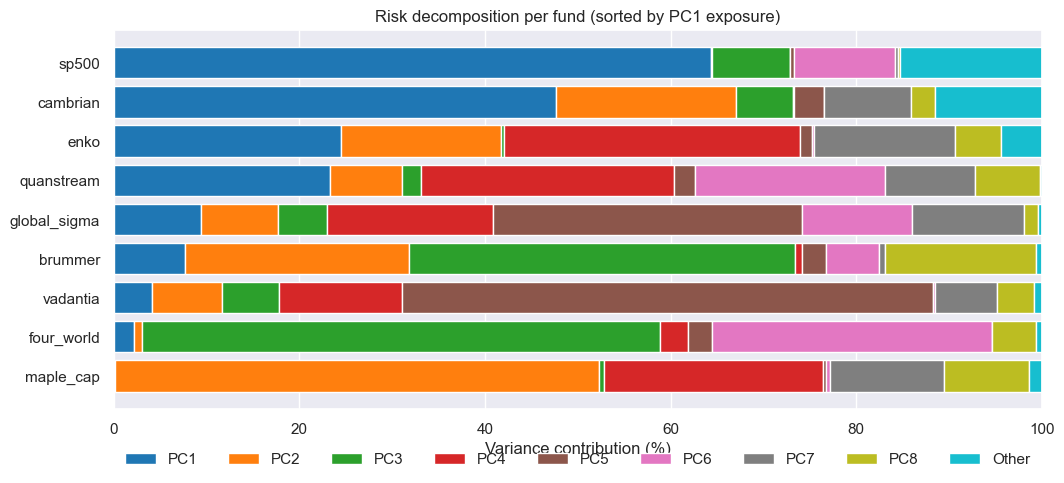

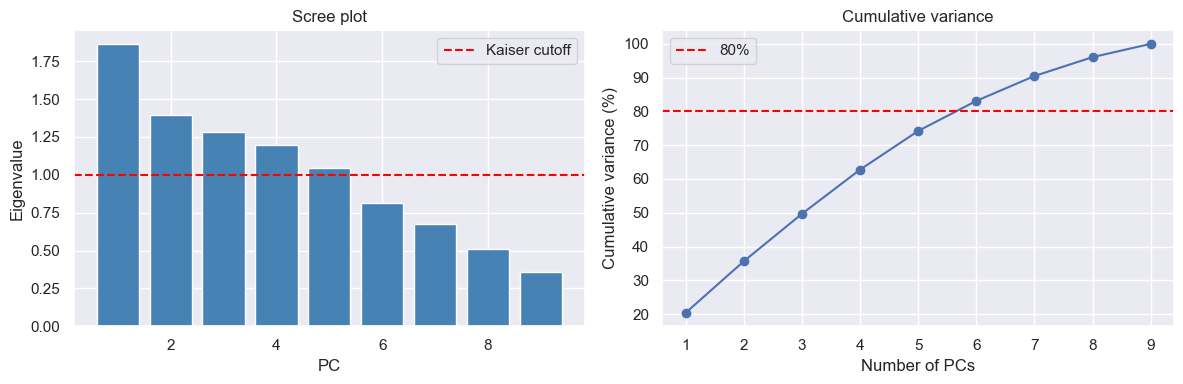

In [119]:
# --- Risk decomposition per fund ---
n_show = min(8, N)

# Variance of fund i from PC k = (eigenvector_ik)^2 * eigenvalue_k
risk_contrib = (pca_full.components_.T ** 2) * eigenvalues  # (N_funds, N_pcs)

# Keep top PCs, lump the rest into 'Other'
top = risk_contrib[:, :n_show]
other = risk_contrib[:, n_show:].sum(axis=1, keepdims=True)
full = np.hstack([top, other])
risk_pct = full / full.sum(axis=1, keepdims=True) * 100

# Sort funds by PC1 exposure (concentrators at top, diversifiers at bottom)
order = np.argsort(-risk_pct[:, 0])
funds_sorted = df_clean.columns[order]
risk_pct_sorted = risk_pct[order]

labels = [f'PC{i+1}' for i in range(n_show)] + ['Other']
colors = plt.cm.tab10(np.linspace(0, 1, len(labels)))

fig, ax = plt.subplots(figsize=(11, max(5, 0.32 * N)))
left = np.zeros(N)
for k, lab in enumerate(labels):
    ax.barh(range(N), risk_pct_sorted[:, k], left=left, label=lab, color=colors[k])
    left += risk_pct_sorted[:, k]

ax.set_yticks(range(N))
ax.set_yticklabels(funds_sorted)
ax.invert_yaxis()
ax.set_xlabel('Variance contribution (%)')
ax.set_title('Risk decomposition per fund (sorted by PC1 exposure)')
ax.set_xlim(0, 100)
ax.legend(ncol=len(labels), loc='upper center', bbox_to_anchor=(0.5, -0.08), frameon=False)
plt.tight_layout()
plt.show()

# --- Scree + cumulative variance (companion diagnostic) ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(range(1, N+1), eigenvalues, color='steelblue')
axes[0].axhline(1, color='red', linestyle='--', label='Kaiser cutoff')
axes[0].set_xlabel('PC'); axes[0].set_ylabel('Eigenvalue')
axes[0].set_title('Scree plot'); axes[0].legend()

axes[1].plot(range(1, N+1), cumulative*100, marker='o')
axes[1].axhline(80, color='red', linestyle='--', label='80%')
axes[1].set_xlabel('Number of PCs'); axes[1].set_ylabel('Cumulative variance (%)')
axes[1].set_title('Cumulative variance'); axes[1].legend()
plt.tight_layout()
plt.show()

## Bootstrapping

BOOTSTRAP RESULTS (2000 resamples, T=70 months, N=9 funds)
Metric      Point     Mean      5th %     95th %    Std     
----------------------------------------------------------------------
PC1         0.204     0.227     0.200     0.262     0.019     
Top3        0.497     0.552     0.518     0.590     0.022     
ENB         8.140     7.691     7.349     7.986     0.195     
Kaiser      5.0       4.2       4.0       5.0       0.5       

--- Probability metrics hold under resampling ---
  P(PC1  <= 0.30):    100.0%
  P(Top3 <= 0.60):    97.4%
  P(ENB  >= N/2):     100.0%
  P(Kaiser >= 5):     24.7%


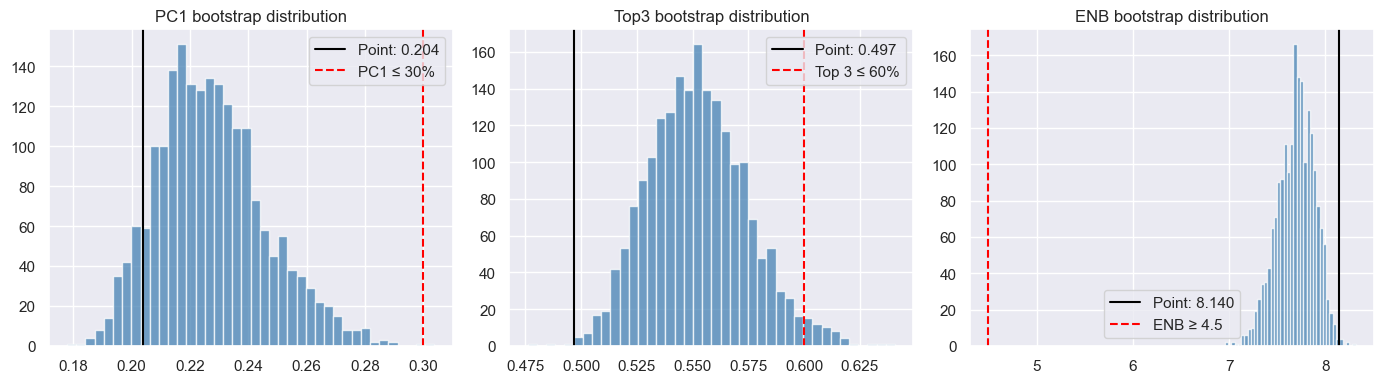

In [120]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

def pca_metrics(returns_array):
    """Run PCA on a returns array and return key diversification metrics."""
    scaled = StandardScaler().fit_transform(returns_array)
    pca = PCA().fit(scaled)
    ratios = pca.explained_variance_ratio_
    eigenvalues = pca.explained_variance_
    p = ratios[ratios > 1e-12]
    enb = float(np.exp(-np.sum(p * np.log(p))))
    return {
        'PC1': ratios[0],
        'Top3': ratios[:3].sum(),
        'ENB': enb,
        'Kaiser': int((eigenvalues > 1).sum()),
    }

# --- Bootstrap ---
n_boot = 2000
rng = np.random.default_rng(42)
T, N = df_clean.shape
results = []

for _ in range(n_boot):
    # Resample rows (months) with replacement — preserves cross-sectional structure
    idx = rng.integers(0, T, size=T)
    sample = df_clean.values[idx]
    results.append(pca_metrics(sample))

boot_df = pd.DataFrame(results)

# --- Summary stats with confidence intervals ---
print("=" * 70)
print(f"BOOTSTRAP RESULTS ({n_boot} resamples, T={T} months, N={N} funds)")
print("=" * 70)
print(f"{'Metric':<12}{'Point':<10}{'Mean':<10}{'5th %':<10}{'95th %':<10}{'Std':<8}")
print("-" * 70)

point = pca_metrics(df_clean.values)
for metric in ['PC1', 'Top3', 'ENB', 'Kaiser']:
    vals = boot_df[metric]
    fmt = "{:<10.3f}" if metric != 'Kaiser' else "{:<10.1f}"
    print(f"{metric:<12}" + fmt.format(point[metric]) +
          fmt.format(vals.mean()) +
          fmt.format(vals.quantile(0.05)) +
          fmt.format(vals.quantile(0.95)) +
          fmt.format(vals.std()))

# --- Probability of passing each test ---
print("\n--- Probability metrics hold under resampling ---")
print(f"  P(PC1  <= 0.30):    {(boot_df['PC1']  <= 0.30).mean():.1%}")
print(f"  P(Top3 <= 0.60):    {(boot_df['Top3'] <= 0.60).mean():.1%}")
print(f"  P(ENB  >= N/2):     {(boot_df['ENB']  >= N/2).mean():.1%}")
print(f"  P(Kaiser >= 5):     {(boot_df['Kaiser'] >= 5).mean():.1%}")

# --- Visualize the bootstrap distributions ---
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, metric, threshold, label in [
    (axes[0], 'PC1',  0.30, 'PC1 ≤ 30%'),
    (axes[1], 'Top3', 0.60, 'Top 3 ≤ 60%'),
    (axes[2], 'ENB',  N/2,  f'ENB ≥ {N/2}'),
]:
    ax.hist(boot_df[metric], bins=40, color='steelblue', alpha=0.75)
    ax.axvline(point[metric], color='black', linestyle='-', label=f'Point: {point[metric]:.3f}')
    ax.axvline(threshold, color='red', linestyle='--', label=label)
    ax.set_title(f'{metric} bootstrap distribution')
    ax.legend()
plt.tight_layout()
plt.show()

SAMPLE GEOMETRY
Observations (T):      70
Funds (N):             9
Ratio T/N:             7.78
Verdict:               NOISY — eigenvectors only beginning to stabilize

Condition number κ:    5.2
                       well-conditioned

MARCHENKO–PASTUR SIGNAL/NOISE SEPARATION
MP upper bound λ+:     1.846
MP lower bound λ-:     0.411
Eigenvalues > λ+:      0   ← estimated 'real' factors
Eigenvalues in bulk:   9   ← noise

EIGENVALUE GAPS  (small gap ⇒ unstable eigenvector)
PC    λ_k         λ_k − λ_(k+1)     Gap/λ_k       Flag    
------------------------------------------------------------
PC1   1.861       0.467             25.12%                
PC2   1.393       0.111             7.99%         SMALL   
PC3   1.282       0.087             6.82%         SMALL   
PC4   1.195       0.148             12.39%                
PC5   1.047       0.235             22.43%                

BOOTSTRAP 95% CIs FOR TOP EIGENVALUES  (500 block draws, block=4m)
PC    Point       2.5%        97.5%     

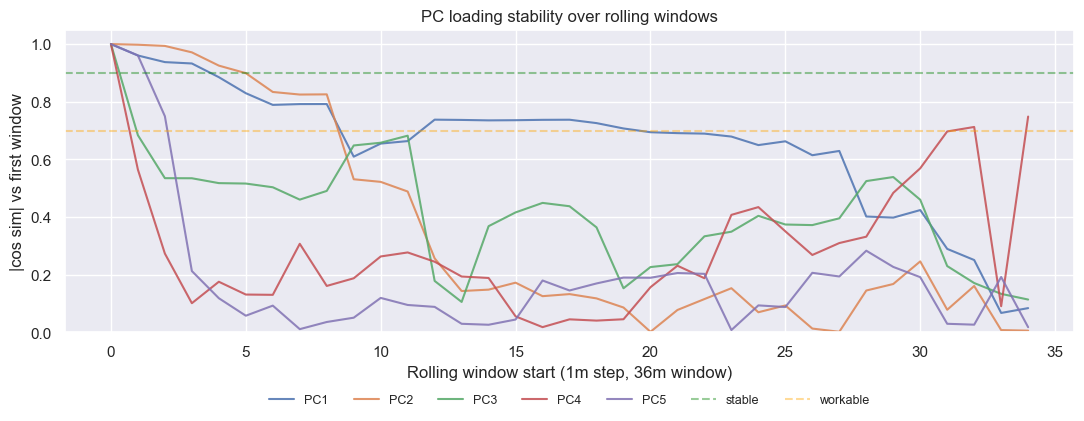

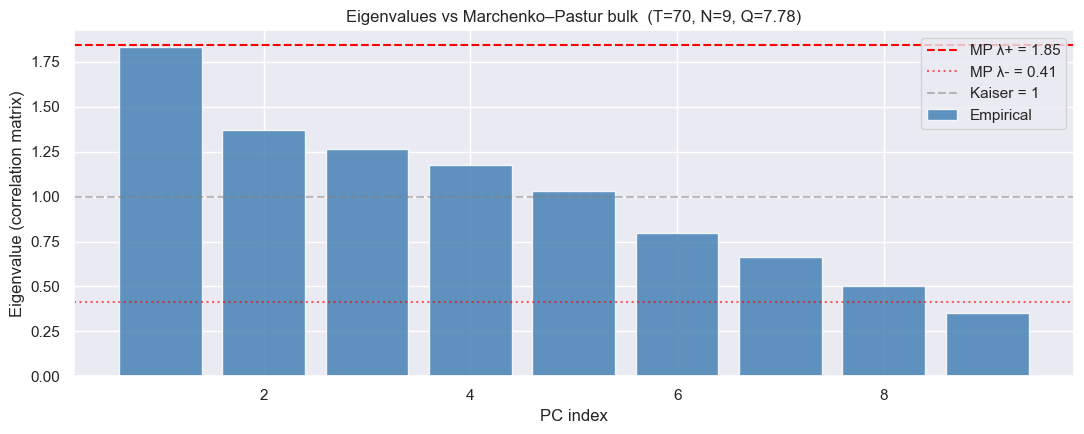


STABILITY SCORECARD
  T/N >= 10                        FAIL
  Condition number < 1e3           PASS
  MP signal factors >= 4           FAIL
  PC1 gap >= 10%                   PASS
  Krzanowski(5) >= 0.85            FAIL
  Rolling mean |cos| >= 0.85       FAIL


In [121]:
import numpy as np
from numpy.linalg import eigh

# ============================================================
# 1. SAMPLE GEOMETRY: T/N & CONDITION NUMBER
# ============================================================
T, N = scaled_returns.shape
cov_matrix  = np.cov(scaled_returns, rowvar=False)
corr_matrix = np.corrcoef(scaled_returns, rowvar=False)

print("=" * 60)
print("SAMPLE GEOMETRY")
print("=" * 60)
print(f"Observations (T):      {T}")
print(f"Funds (N):             {N}")
print(f"Ratio T/N:             {T/N:.2f}")

if   T/N < 5:  tn_v = "VERY NOISY — top PCs barely trustworthy"
elif T/N < 10: tn_v = "NOISY — eigenvectors only beginning to stabilize"
elif T/N < 30: tn_v = "WORKABLE — usable for allocation with care"
else:          tn_v = "SOLID — well-conditioned for allocation"
print(f"Verdict:               {tn_v}")

kappa = np.linalg.cond(cov_matrix)
print(f"\nCondition number κ:    {kappa:,.1f}")
if   kappa < 1e3:  print("                       well-conditioned")
elif kappa < 1e4:  print("                       borderline — consider shrinkage")
else:              print("                       ILL-CONDITIONED — shrinkage strongly recommended")

# ============================================================
# 2. MARCHENKO–PASTUR SIGNAL/NOISE
# ============================================================
lam_plus  = (1 + np.sqrt(N/T))**2
lam_minus = (1 - np.sqrt(N/T))**2
eig_corr  = np.sort(eigh(corr_matrix)[0])[::-1]
n_signal  = int(np.sum(eig_corr > lam_plus))

print("\n" + "=" * 60)
print("MARCHENKO–PASTUR SIGNAL/NOISE SEPARATION")
print("=" * 60)
print(f"MP upper bound λ+:     {lam_plus:.3f}")
print(f"MP lower bound λ-:     {lam_minus:.3f}")
print(f"Eigenvalues > λ+:      {n_signal}   ← estimated 'real' factors")
print(f"Eigenvalues in bulk:   {N - n_signal}   ← noise")

# ============================================================
# 3. EIGENVALUE GAPS (Davis–Kahan)
# ============================================================
top_k = min(5, N)
print("\n" + "=" * 60)
print("EIGENVALUE GAPS  (small gap ⇒ unstable eigenvector)")
print("=" * 60)
print(f"{'PC':<6}{'λ_k':<12}{'λ_k − λ_(k+1)':<18}{'Gap/λ_k':<14}{'Flag':<8}")
print("-" * 60)
for k in range(min(top_k, len(eigenvalues) - 1)):
    gap = eigenvalues[k] - eigenvalues[k+1]
    rel = gap / eigenvalues[k]
    flag = "" if rel >= 0.10 else "SMALL"
    print(f"PC{k+1:<4}{eigenvalues[k]:<12.3f}{gap:<18.3f}{rel:<14.2%}{flag:<8}")

# ============================================================
# 4. BOOTSTRAP CIs (block bootstrap, sign-aligned)
# ============================================================
def block_bootstrap_pca(X, n_boot=500, block_size=4, top_k=5, seed=42):
    rng = np.random.default_rng(seed)
    T, N = X.shape
    n_blocks = int(np.ceil(T / block_size))

    ev0, V0 = eigh(np.cov(X, rowvar=False))
    order   = np.argsort(ev0)[::-1]
    ev0, V0 = ev0[order], V0[:, order]

    boot_ev = np.zeros((n_boot, top_k))
    boot_V  = np.zeros((n_boot, N, top_k))

    for b in range(n_boot):
        starts = rng.integers(0, T - block_size + 1, size=n_blocks)
        idx    = np.concatenate([np.arange(s, s + block_size) for s in starts])[:T]
        evb, Vb = eigh(np.cov(X[idx], rowvar=False))
        o = np.argsort(evb)[::-1][:top_k]
        evb, Vb = evb[o], Vb[:, o]
        # sign-align against original
        for k in range(top_k):
            if np.dot(Vb[:, k], V0[:, k]) < 0:
                Vb[:, k] *= -1
        boot_ev[b] = evb
        boot_V[b]  = Vb
    return boot_ev, boot_V, V0[:, :top_k]

boot_ev, boot_V, V0 = block_bootstrap_pca(scaled_returns, n_boot=500,
                                          block_size=4, top_k=top_k)

print("\n" + "=" * 60)
print("BOOTSTRAP 95% CIs FOR TOP EIGENVALUES  (500 block draws, block=4m)")
print("=" * 60)
print(f"{'PC':<6}{'Point':<12}{'2.5%':<12}{'97.5%':<12}{'Width':<10}")
print("-" * 60)
overlap = []
for k in range(top_k):
    lo, hi = np.percentile(boot_ev[:, k], [2.5, 97.5])
    print(f"PC{k+1:<4}{eigenvalues[k]:<12.3f}{lo:<12.3f}{hi:<12.3f}{hi-lo:<10.3f}")
    if k > 0:
        prev_hi = np.percentile(boot_ev[:, k-1], 2.5)
        if hi > prev_hi:
            overlap.append((k, k+1))
if overlap:
    print("⚠  Overlapping CIs between adjacent PCs:",
          ", ".join([f"PC{a}/PC{b}" for a, b in overlap]),
          "— these PCs are not separately identified.")

print("\n--- Loading sign-stability (% of bootstraps matching point estimate) ---")
header = f"{'Fund':<25}" + "".join([f"PC{k+1:<8}" for k in range(top_k)])
print(header)
print("-" * len(header))
for i, fund in enumerate(df_clean.columns):
    cells = []
    for k in range(top_k):
        s = np.sign(V0[i, k])
        frac = 0.5 if s == 0 else np.mean(np.sign(boot_V[:, i, k]) == s)
        cells.append(f"{frac*100:>5.0f}%  ")
    print(f"{fund:<25}" + "".join(cells))

# ============================================================
# 5. KRZANOWSKI SUBSPACE SIMILARITY (split-half)
# ============================================================
def top_k_loadings(X, k):
    ev, v = eigh(np.cov(X, rowvar=False))
    o = np.argsort(ev)[::-1][:k]
    return v[:, o]

half = T // 2
X1, X2 = scaled_returns[:half], scaled_returns[half:]

print("\n" + "=" * 60)
print("KRZANOWSKI SIMILARITY  (first half vs second half)")
print("=" * 60)
print(f"{'k':<6}{'Krzanowski/k':<18}{'Verdict':<20}")
print("-" * 60)
for k in range(1, min(6, N) + 1):
    V1, V2 = top_k_loadings(X1, k), top_k_loadings(X2, k)
    krz = np.trace(V1.T @ V2 @ V2.T @ V1) / k
    v = "stable" if krz > 0.9 else "workable" if krz > 0.7 else "UNRELIABLE"
    print(f"{k:<6}{krz:<18.3f}{v:<20}")

# ============================================================
# 6. ROLLING-WINDOW STABILITY  (|cos sim| vs first window)
# ============================================================
window = 36
if T >= window + 12:
    n_w = T - window + 1
    ref = top_k_loadings(scaled_returns[:window], top_k)
    cos_sim = np.zeros((n_w, top_k))
    prev = ref.copy()
    for w in range(n_w):
        Vw = top_k_loadings(scaled_returns[w:w+window], top_k)
        for k in range(top_k):
            if np.dot(Vw[:, k], prev[:, k]) < 0:
                Vw[:, k] *= -1
            cos_sim[w, k] = abs(np.dot(Vw[:, k], ref[:, k]))
        prev = Vw

    print("\n" + "=" * 60)
    print(f"ROLLING-WINDOW STABILITY  (window={window}m)")
    print("=" * 60)
    print(f"{'PC':<6}{'Mean |cos|':<14}{'Min |cos|':<14}{'Verdict':<20}")
    print("-" * 60)
    for k in range(top_k):
        m, mn = cos_sim[:, k].mean(), cos_sim[:, k].min()
        v = "stable" if m > 0.9 else "workable" if m > 0.7 else "UNSTABLE"
        print(f"PC{k+1:<4}{m:<14.3f}{mn:<14.3f}{v:<20}")

    fig, ax = plt.subplots(figsize=(11, 4.5))
    for k in range(top_k):
        ax.plot(cos_sim[:, k], label=f'PC{k+1}', alpha=0.85)
    ax.axhline(0.9, color='green',  linestyle='--', alpha=0.4, label='stable')
    ax.axhline(0.7, color='orange', linestyle='--', alpha=0.4, label='workable')
    ax.set_ylim(0, 1.05)
    ax.set_xlabel(f'Rolling window start (1m step, {window}m window)')
    ax.set_ylabel('|cos sim| vs first window')
    ax.set_title('PC loading stability over rolling windows')
    ax.legend(ncol=top_k+2, loc='lower center', bbox_to_anchor=(0.5, -0.28),
              frameon=False, fontsize=9)
    plt.tight_layout(); plt.show()
else:
    print("\nNot enough observations for rolling-window stability "
          f"(need ≥ {window+12}, have {T}).")

# ============================================================
# 7. SCREE WITH MP BULK OVERLAY
# ============================================================
fig, ax = plt.subplots(figsize=(11, 4.5))
x = np.arange(1, N+1)
ax.bar(x, eig_corr, color='steelblue', alpha=0.85, label='Empirical')
ax.axhline(lam_plus,  color='red',  linestyle='--', label=f'MP λ+ = {lam_plus:.2f}')
ax.axhline(lam_minus, color='red',  linestyle=':',  alpha=0.6,
           label=f'MP λ- = {lam_minus:.2f}')
ax.axhline(1, color='gray', linestyle='--', alpha=0.5, label='Kaiser = 1')
ax.set_xlabel('PC index'); ax.set_ylabel('Eigenvalue (correlation matrix)')
ax.set_title(f'Eigenvalues vs Marchenko–Pastur bulk  '
             f'(T={T}, N={N}, Q={T/N:.2f})')
ax.legend()
plt.tight_layout(); plt.show()

# ============================================================
# 8. STABILITY SCORECARD
# ============================================================
krz_5 = (lambda k: np.trace(top_k_loadings(X1,k).T @ top_k_loadings(X2,k)
                            @ top_k_loadings(X2,k).T @ top_k_loadings(X1,k))/k)(min(5,N))
mean_cos_top = cos_sim[:, :top_k].mean() if T >= window+12 else np.nan

stability_checks = [
    ("T/N >= 10",                 T/N >= 10),
    ("Condition number < 1e3",    kappa < 1e3),
    ("MP signal factors >= 4",    n_signal >= 4),
    ("PC1 gap >= 10%",            (eigenvalues[0]-eigenvalues[1])/eigenvalues[0] >= 0.10),
    ("Krzanowski(5) >= 0.85",     krz_5 >= 0.85),
    ("Rolling mean |cos| >= 0.85", (not np.isnan(mean_cos_top)) and mean_cos_top >= 0.85),
]
print("\n" + "=" * 60)
print("STABILITY SCORECARD")
print("=" * 60)
for label, ok in stability_checks:
    print(f"  {label:<32} {'PASS' if ok else 'FAIL'}")

LEDOIT–WOLF SHRINKAGE
Shrinkage intensity δ:   1.000   (0 = sample cov, 1 = pure target)
                         heavy shrinkage — sample cov very noisy

SAMPLE vs SHRUNK — KEY METRICS
Metric                      Sample        Shrunk        
------------------------------------------------------------
Condition number            5.19          1.00          
PC1 variance share          20.38         11.11         
Top 3 variance share        49.68         33.33         
ENB                         8.140         9.000         
MP signal factors           0             0             

EIGENVALUE SPECTRA  (correlation matrix)
PC    Sample λ      Shrunk λ      Δ         
------------------------------------------------------------
PC1   1.834         1.000         -0.834
PC2   1.373         1.000         -0.373
PC3   1.264         1.000         -0.264
PC4   1.177         1.000         -0.177
PC5   1.032         1.000         -0.032
PC6   0.800         1.000         +0.200
PC7   0.663      

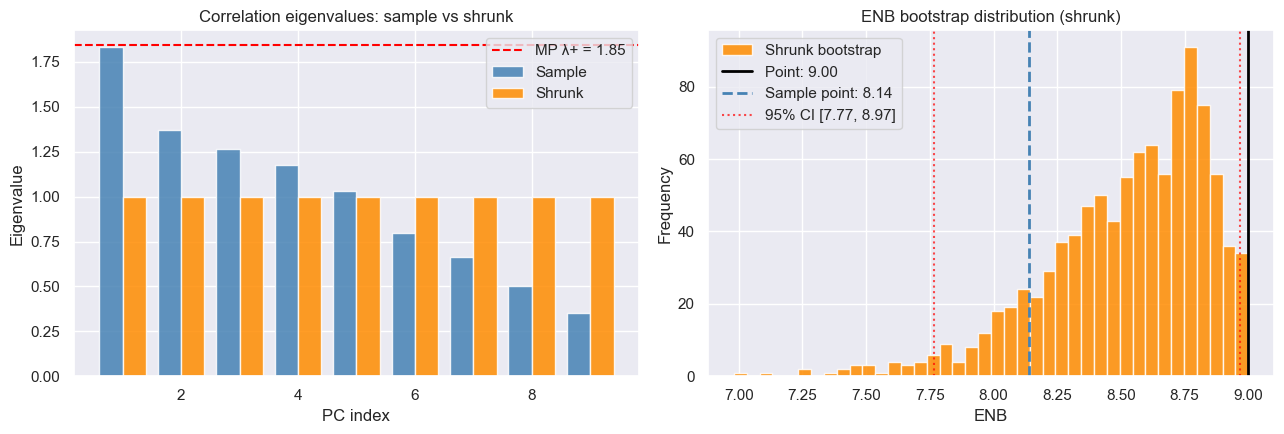

In [122]:
from sklearn.covariance import LedoitWolf
import numpy as np
from numpy.linalg import eigh

# ============================================================
# LEDOIT–WOLF SHRINKAGE
# ============================================================
lw = LedoitWolf().fit(scaled_returns)
cov_shrunk = lw.covariance_
shrinkage_intensity = lw.shrinkage_

# Build shrunk *correlation* matrix for MP comparison (apples-to-apples)
d = np.sqrt(np.diag(cov_shrunk))
corr_shrunk = cov_shrunk / np.outer(d, d)

# Eigendecomposition
ev_shrunk_cov,  V_shrunk_cov  = eigh(cov_shrunk)
ev_shrunk_corr, V_shrunk_corr = eigh(corr_shrunk)
order = np.argsort(ev_shrunk_cov)[::-1]
ev_shrunk_cov, V_shrunk_cov = ev_shrunk_cov[order], V_shrunk_cov[:, order]
ev_shrunk_corr = np.sort(ev_shrunk_corr)[::-1]

# Variance shares & ENB on shrunk spectrum
p_shrunk = ev_shrunk_cov / ev_shrunk_cov.sum()
ENB_shrunk = float(np.exp(-np.sum(p_shrunk[p_shrunk > 1e-12] *
                                  np.log(p_shrunk[p_shrunk > 1e-12]))))

print("=" * 60)
print("LEDOIT–WOLF SHRINKAGE")
print("=" * 60)
print(f"Shrinkage intensity δ:   {shrinkage_intensity:.3f}   "
      f"(0 = sample cov, 1 = pure target)")
if   shrinkage_intensity < 0.15: msg = "data-driven low — sample cov is fine"
elif shrinkage_intensity < 0.40: msg = "moderate shrinkage — typical for T/N ~ 8"
else:                            msg = "heavy shrinkage — sample cov very noisy"
print(f"                         {msg}")

# ============================================================
# SIDE-BY-SIDE COMPARISON
# ============================================================
kappa_sample = np.linalg.cond(cov_matrix)
kappa_shrunk = np.linalg.cond(cov_shrunk)

lam_plus  = (1 + np.sqrt(N/T))**2
n_sig_sample = int(np.sum(np.sort(eigh(corr_matrix)[0])[::-1] > lam_plus))
n_sig_shrunk = int(np.sum(ev_shrunk_corr > lam_plus))

p_sample = explained_ratio
ENB_sample = float(np.exp(-np.sum(p_sample[p_sample > 1e-12] *
                                  np.log(p_sample[p_sample > 1e-12]))))

print("\n" + "=" * 60)
print("SAMPLE vs SHRUNK — KEY METRICS")
print("=" * 60)
print(f"{'Metric':<28}{'Sample':<14}{'Shrunk':<14}")
print("-" * 60)
print(f"{'Condition number':<28}{kappa_sample:<14.2f}{kappa_shrunk:<14.2f}")
print(f"{'PC1 variance share':<28}{p_sample[0]*100:<14.2f}{p_shrunk[0]*100:<14.2f}")
print(f"{'Top 3 variance share':<28}{p_sample[:3].sum()*100:<14.2f}"
      f"{p_shrunk[:3].sum()*100:<14.2f}")
print(f"{'ENB':<28}{ENB_sample:<14.3f}{ENB_shrunk:<14.3f}")
print(f"{'MP signal factors':<28}{n_sig_sample:<14d}{n_sig_shrunk:<14d}")

# ============================================================
# EIGENVALUE SPECTRA SIDE-BY-SIDE
# ============================================================
print("\n" + "=" * 60)
print("EIGENVALUE SPECTRA  (correlation matrix)")
print("=" * 60)
ev_sample_corr = np.sort(eigh(corr_matrix)[0])[::-1]
print(f"{'PC':<6}{'Sample λ':<14}{'Shrunk λ':<14}{'Δ':<10}")
print("-" * 60)
for k in range(min(N, 9)):
    delta = ev_shrunk_corr[k] - ev_sample_corr[k]
    print(f"PC{k+1:<4}{ev_sample_corr[k]:<14.3f}{ev_shrunk_corr[k]:<14.3f}"
          f"{delta:+.3f}")

# ============================================================
# KRZANOWSKI ON SHRUNK COVARIANCE
# ============================================================
def top_k_loadings_shrunk(X, k):
    cov = LedoitWolf().fit(X).covariance_
    ev, v = eigh(cov)
    o = np.argsort(ev)[::-1][:k]
    return v[:, o]

half = T // 2
X1, X2 = scaled_returns[:half], scaled_returns[half:]

print("\n" + "=" * 60)
print("KRZANOWSKI SIMILARITY — SAMPLE vs SHRUNK")
print("=" * 60)
print(f"{'k':<6}{'Sample':<14}{'Shrunk':<14}{'Improvement':<14}")
print("-" * 60)
for k in range(1, min(6, N) + 1):
    V1s = top_k_loadings(X1, k); V2s = top_k_loadings(X2, k)
    krz_s = np.trace(V1s.T @ V2s @ V2s.T @ V1s) / k

    V1h = top_k_loadings_shrunk(X1, k); V2h = top_k_loadings_shrunk(X2, k)
    krz_h = np.trace(V1h.T @ V2h @ V2h.T @ V1h) / k

    print(f"{k:<6}{krz_s:<14.3f}{krz_h:<14.3f}{krz_h-krz_s:+.3f}")

# ============================================================
# BOOTSTRAP ENB CI ON SHRUNK COVARIANCE
# ============================================================
def bootstrap_enb_shrunk(X, n_boot=1000, block_size=4, seed=42):
    rng = np.random.default_rng(seed)
    T, N = X.shape
    n_blocks = int(np.ceil(T / block_size))
    enbs = np.zeros(n_boot)
    for b in range(n_boot):
        starts = rng.integers(0, T - block_size + 1, size=n_blocks)
        idx    = np.concatenate([np.arange(s, s + block_size) for s in starts])[:T]
        cov_b  = LedoitWolf().fit(X[idx]).covariance_
        evb    = eigh(cov_b)[0]
        pb     = evb / evb.sum()
        pb     = pb[pb > 1e-12]
        enbs[b] = float(np.exp(-np.sum(pb * np.log(pb))))
    return enbs

enbs_shrunk = bootstrap_enb_shrunk(scaled_returns, n_boot=1000, block_size=4)
lo, hi = np.percentile(enbs_shrunk, [2.5, 97.5])

print("\n" + "=" * 60)
print("ENB BOOTSTRAP CI — SHRUNK")
print("=" * 60)
print(f"Point estimate:        {ENB_shrunk:.3f}")
print(f"95% CI:                [{lo:.3f}, {hi:.3f}]")
print(f"Width:                 {hi-lo:.3f}")

# ============================================================
# COMPARISON PLOT
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

x = np.arange(1, N+1)
axes[0].bar(x - 0.2, ev_sample_corr, width=0.4,
            color='steelblue', label='Sample', alpha=0.85)
axes[0].bar(x + 0.2, ev_shrunk_corr, width=0.4,
            color='darkorange', label='Shrunk', alpha=0.85)
axes[0].axhline(lam_plus, color='red', linestyle='--',
                label=f'MP λ+ = {lam_plus:.2f}')
axes[0].set_xlabel('PC index'); axes[0].set_ylabel('Eigenvalue')
axes[0].set_title('Correlation eigenvalues: sample vs shrunk')
axes[0].legend()

axes[1].hist(enbs_shrunk, bins=40, color='darkorange',
             alpha=0.85, label='Shrunk bootstrap')
axes[1].axvline(ENB_shrunk, color='black', linewidth=2,
                label=f'Point: {ENB_shrunk:.2f}')
axes[1].axvline(ENB_sample, color='steelblue', linewidth=2,
                linestyle='--', label=f'Sample point: {ENB_sample:.2f}')
axes[1].axvline(lo, color='red', linestyle=':', alpha=0.7)
axes[1].axvline(hi, color='red', linestyle=':', alpha=0.7,
                label=f'95% CI [{lo:.2f}, {hi:.2f}]')
axes[1].set_xlabel('ENB'); axes[1].set_ylabel('Frequency')
axes[1].set_title('ENB bootstrap distribution (shrunk)')
axes[1].legend()
plt.tight_layout(); plt.show()